In [3]:
# !pip install matplotlib

In [4]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

## Train Data

In [5]:
data_path = '../data/'

train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))
train_df.shape

(12457, 4)

In [6]:
sample_dialogue = train_df.loc[0, 'dialogue']
print(sample_dialogue)
print(len(sample_dialogue))
sample_summary = train_df.loc[0, 'summary']
print(sample_summary)
print(len(sample_summary))

#Person1#: 안녕하세요, 스미스씨. 저는 호킨스 의사입니다. 오늘 왜 오셨나요?
#Person2#: 건강검진을 받는 것이 좋을 것 같아서요.
#Person1#: 그렇군요, 당신은 5년 동안 건강검진을 받지 않았습니다. 매년 받아야 합니다.
#Person2#: 알고 있습니다. 하지만 아무 문제가 없다면 왜 의사를 만나러 가야 하나요?
#Person1#: 심각한 질병을 피하는 가장 좋은 방법은 이를 조기에 발견하는 것입니다. 그러니 당신의 건강을 위해 최소한 매년 한 번은 오세요.
#Person2#: 알겠습니다.
#Person1#: 여기 보세요. 당신의 눈과 귀는 괜찮아 보입니다. 깊게 숨을 들이쉬세요. 스미스씨, 담배 피우시나요?
#Person2#: 네.
#Person1#: 당신도 알다시피, 담배는 폐암과 심장병의 주요 원인입니다. 정말로 끊으셔야 합니다. 
#Person2#: 수백 번 시도했지만, 습관을 버리는 것이 어렵습니다.
#Person1#: 우리는 도움이 될 수 있는 수업과 약물들을 제공하고 있습니다. 나가기 전에 더 많은 정보를 드리겠습니다.
#Person2#: 알겠습니다, 감사합니다, 의사선생님.
575
스미스씨가 건강검진을 받고 있고, 호킨스 의사는 매년 건강검진을 받는 것을 권장합니다. 호킨스 의사는 스미스씨가 담배를 끊는 데 도움이 될 수 있는 수업과 약물에 대한 정보를 제공할 것입니다.
107


In [7]:
# dialog 와 summary 각각의 모델 max_length 설정을 위한 길이 확인
train_dialog_length = train_df['dialogue'].apply(lambda x:len(x))
train_summary_length = train_df['summary'].apply(lambda x:len(x))

print("대화 길이에 대한 정보")
print(train_dialog_length.describe())
print("요약문 길이에 대한 정보")
print(train_summary_length.describe())

대화 길이에 대한 정보
count    12457.000000
mean       438.765112
std        220.134710
min         99.000000
25%        299.000000
50%        396.000000
75%        540.000000
max       2546.000000
Name: dialogue, dtype: float64
요약문 길이에 대한 정보
count    12457.000000
mean        87.397929
std         37.641178
min         19.000000
25%         61.000000
50%         80.000000
75%        106.000000
max        478.000000
Name: summary, dtype: float64


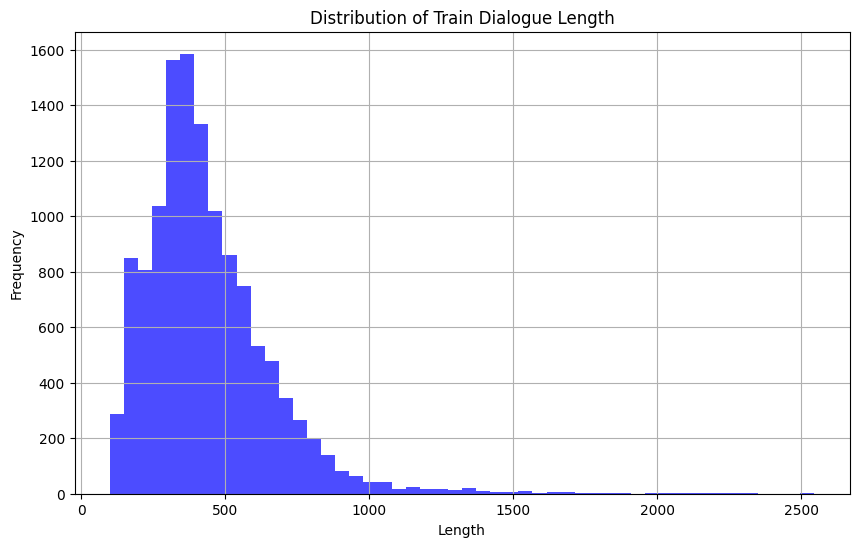

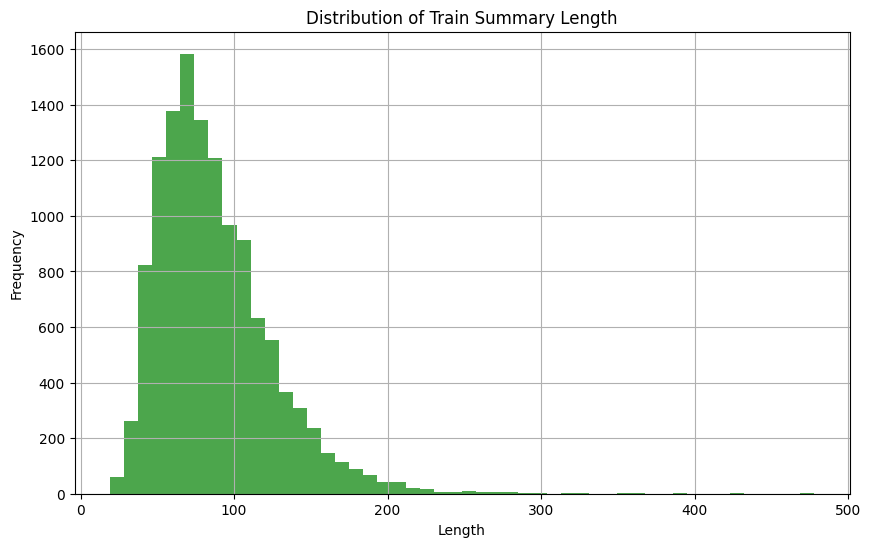

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(train_dialog_length, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Train Dialogue Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(train_summary_length, bins=50, color='green', alpha=0.7)
plt.title('Distribution of Train Summary Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Validation Data

In [10]:
val_df = pd.read_csv(os.path.join(data_path,'dev.csv'))
val_df.shape

(499, 4)

In [11]:
sample_dialogue = val_df.loc[0, 'dialogue']
print(sample_dialogue)
print(len(sample_dialogue))
sample_summary = val_df.loc[0, 'summary']
print(sample_summary)
print(len(sample_summary))

#Person1#: 안녕하세요, 오늘 하루 어떠셨어요? 
#Person2#: 요즘 숨쉬기가 좀 힘들어요.
#Person1#: 최근에 감기 같은 것에 걸리신 적이 있나요?
#Person2#: 아니요, 감기는 아니에요. 그냥 숨을 쉴 때마다 가슴이 무겁게 느껴져요.
#Person1#: 알고 있는 알레르기가 있나요?
#Person2#: 아니요, 알고 있는 알레르기는 없어요.
#Person1#: 이런 증상이 항상 나타나나요, 아니면 활동할 때 주로 나타나나요?
#Person2#: 운동을 할 때 많이 나타나요.
#Person1#: 저는 당신을 폐 전문의에게 보내서 천식에 대한 검사를 받게 할 거예요.
#Person2#: 도와주셔서 감사합니다, 의사 선생님.
366
#Person2#는 숨쉬기에 어려움을 겪는다. 의사는 #Person1#에게 이에 대해 묻고, #Person2#를 폐 전문의에게 보낼 예정이다. 
80


In [12]:
val_dialog_length = val_df['dialogue'].apply(lambda x:len(x))
val_summary_length = val_df['summary'].apply(lambda x:len(x))

print("대화 길이에 대한 정보")
print(val_dialog_length.describe())
print("요약문 길이에 대한 정보")
print(val_summary_length.describe())

대화 길이에 대한 정보
count     499.000000
mean      432.559118
std       206.074045
min       132.000000
25%       299.000000
50%       392.000000
75%       526.000000
max      1484.000000
Name: dialogue, dtype: float64
요약문 길이에 대한 정보
count    499.000000
mean      81.709419
std       35.877381
min       25.000000
25%       55.000000
50%       74.000000
75%       98.000000
max      263.000000
Name: summary, dtype: float64


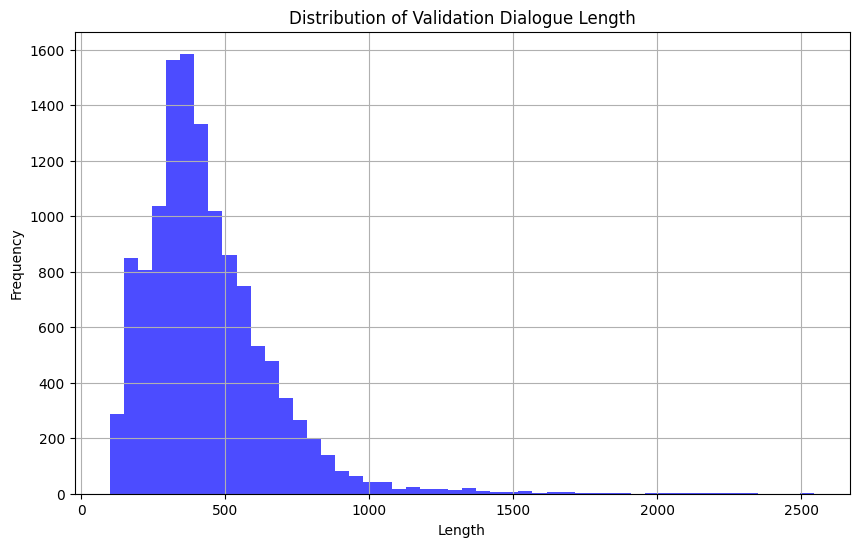

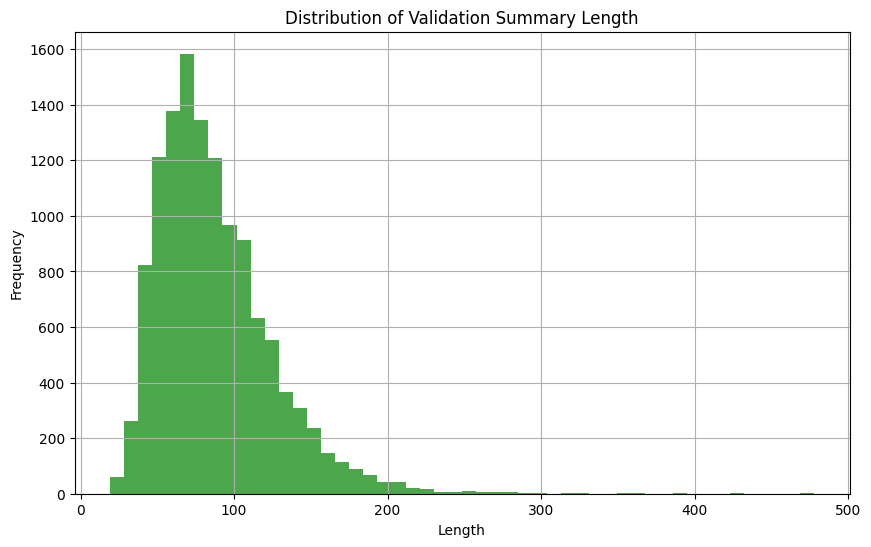

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(train_dialog_length, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Validation Dialogue Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(train_summary_length, bins=50, color='green', alpha=0.7)
plt.title('Distribution of Validation Summary Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Test Data

In [14]:
test_df = pd.read_csv(os.path.join(data_path,'test.csv'))
test_df.shape

(499, 2)

In [15]:
test_df

,fname,dialogue
0,test_0,"#Person1#: 더슨 씨, 받아쓰기 좀 해주세요. \n#Person2#: 네, ..."
1,test_1,#Person1#: 드디어 왔네! 왜 그렇게 오래 걸렸어?\n#Person2#: 또...
2,test_2,"#Person1#: 케이트, 무슨 일이 일어났는지 너는 믿지 못할거야. \n#Per..."
3,test_3,"#Person1#: 생일 축하해, 이건 너를 위한 거야, 브라이언.\n#Person..."
4,test_4,#Person1#: 이 올림픽 공원이 정말 크네요!\n#Person2#: 네. 지금...
...,...,...
494,test_495,"#Person1#: 헤이, 찰리, 학교 끝나고 우리 집에 와서 나랑 비디오 게임 할..."
495,test_496,#Person1#: 어떻게 컨트리 음악에 관심을 가지게 되었나요?\r\n#Perso...
496,test_497,"#Person1#: 실례합니다, 앨리스. 이곳을 사용해본 적이 없는데, 기계를 어떻..."
497,test_498,#Person1#: 매튜? 안녕!\r\n#Person2#: 스티브! 오랜만이네! 얼...


In [16]:
test_dialog_length = test_df['dialogue'].apply(lambda x:len(x))

print("대화 길이에 대한 정보")
print(test_dialog_length.describe())

대화 길이에 대한 정보
count     499.000000
mean      449.312625
std       239.192203
min       109.000000
25%       289.000000
50%       407.000000
75%       559.000000
max      2650.000000
Name: dialogue, dtype: float64


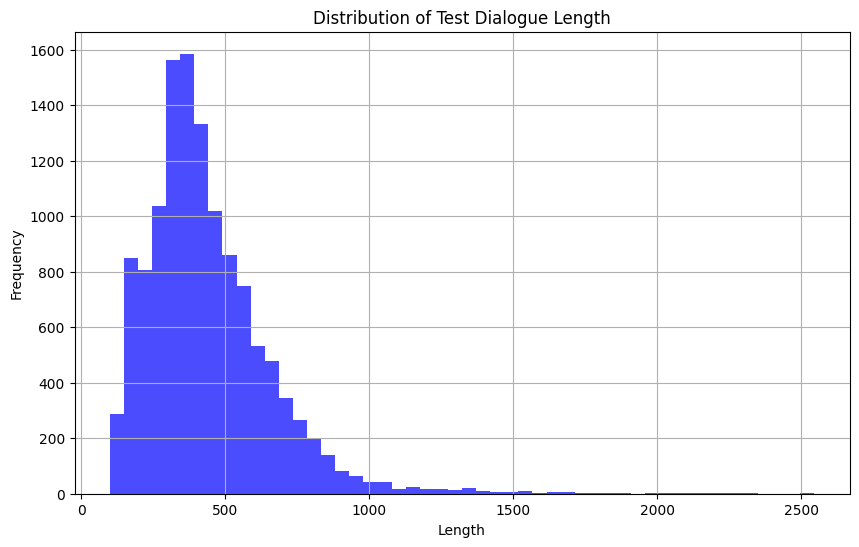

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(train_dialog_length, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Test Dialogue Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## 연속된 자음 및 오타 파악

In [12]:
train_df[train_df['dialogue'].str.contains(re.compile(r'[ㄱ-ㅎㅏ-ㅣ]'))].values

array([['train_3154',
        '#Person1#: 짐! 잘 지내? \n#Person2#: 찰리! 저게 너의 차야? 완전 못생겼네, 친구야! \n#Person1#: 멍청이가 되지마! 이건 1969년형 쉐비 임팔라야! 좀 고쳐야겠지만. 몇 달 안에 이 아기는 완전 멋질 거야! \n#Person2#: 아니야! 이걸 봐! 이게 바로 멋진 차야! \n#Person1#: 아쉽게도 운전자는 완전 바보야. 그런 차를 가질 수 있는 건 아빠가 그만큼 돈이 많아서야. \n#Person2#: 그가 이쪽으로 오고 있어, 차분하게 있어. \n#Person3#: 여러분! 내 차 어때요? 완전 멋지지 않아요? \n#Person1#: 맞아! 여자들이 너를 그 차로 돌아다니는 걸 보면 너에게 줄을 서게 될 거야. \n#Person3#: 정말 그럴까요? \n#Person2#: 확실해! \n#Person3#: 대박! \n#Person1#: 속았어! ㅋㅋ.. 완전 속았어. \n#Person3#: 넌 진짜 나쁜 놈이야, 찰리. 프롬 퀸과 재미있는 시간을 보낼 때, 마지막 웃음은 누가 낼지 봐. \n#Person2#: 친구야, 화내지 마! ',
        '짐은 찰리의 차가 못생겼다고 생각하지만 찰리는 그저 좀 고쳐야 한다고 말한다. 그런 다음 그들은 멋진 차를 가진 #Person3#를 만난다.',
        '\n자동차'],
       ['train_5385',
        '#Person1#: 제 영어 선생님이 저에게 오만과 편견을 읽으라고 하다니 믿을 수가 없어요!\n#Person2#: 왜요! 그건 클래식이에요. 사실, 제가 가장 좋아하는 소설 중 하나예요.\n#Person1#: 하지만 너무 오래됐어요.\n#Person2#: 표지만 보고 책을 판단하지 마세요. 그 내용을 알고 있나요?\n#Person1#: 아니요, 전혀 모르겠어요.\n#Person2#: 먼저, 이것은 19세기 초 배경ㅇ로 설정된 로맨스 소설이에요.\n#Person1#: 로맨스 소설인 줄 몰랐

In [13]:
train_df[train_df['dialogue'].str.contains('ㅇ로')].values

array([['train_5385',
        '#Person1#: 제 영어 선생님이 저에게 오만과 편견을 읽으라고 하다니 믿을 수가 없어요!\n#Person2#: 왜요! 그건 클래식이에요. 사실, 제가 가장 좋아하는 소설 중 하나예요.\n#Person1#: 하지만 너무 오래됐어요.\n#Person2#: 표지만 보고 책을 판단하지 마세요. 그 내용을 알고 있나요?\n#Person1#: 아니요, 전혀 모르겠어요.\n#Person2#: 먼저, 이것은 19세기 초 배경ㅇ로 설정된 로맨스 소설이에요.\n#Person1#: 로맨스 소설인 줄 몰랐어요. 주요 스토리라인은 뭔가요?\n#Person2#: 아버지가 그의 다섯 딸 중 한 명을 결혼시키려고 노력하는 이야기에요.\n#Person1#: 그는 왜 그렇게 하려고 하나요?\n#Person2#: 그가 아들이 없기 때문에, 딸 중 한 명이 부유한 남자와 결혼하기를 바라는 거죠. 그렇게 하면 그의 모든 딸들이 잘 살 수 있을거니까요.\n#Person1#: 그들은 아버지의 상속을 받지 않나요?\n#Person2#: 아니요, 그게 문제죠. 그들은 부유하지만, 그가 죽으면 그의 집은 그의 사촌에게 갈 거예요. 그래서 그가 죽으면, 딸들은 아무것도 가지지 못할 거예요.\n#Person1#: 이해했어요. 이건 흥미롭네요! 아마 제 선생님이 그렇게 나쁘지 않은 건지도 몰라요.\n#Person2#: 그럼, 소설을 읽을 건지 영화를 볼 건지 결정했나요?\n#Person1#: 영화도 있어요? 제 선생님이 그런 건 말해주지 않았어요!\n#Person2#: 아마 그녀가 먼저 책을 읽게 하고 싶어서 그럴 거예요.\n#Person1#: 훨씬 덜 시간이 걸릴 텐데. . .\n#Person2#: 이렇게 어떨까요. 책을 다 읽으면, 저와 함께 영화를 보러 가요.\n#Person1#: 좋아요. 그럼 그렇게 하죠.',
        '#Person1#의 선생님이 오만과 편견을 읽게 만들었지만, #Person1#은 그 소설이 너무 오래되었다고 생각한다.

In [14]:
train_df['dialogue'] = train_df['dialogue'].apply(lambda x:x.replace('ㅇ로', '으로'))
train_df[train_df['dialogue'].apply(lambda x:x.find('ㅇ로')!= -1)].values

array([], shape=(0, 4), dtype=object)

In [15]:
train_df[train_df['dialogue'].str.contains('제ㅏ')].values

array([['train_7201',
        '#Person1#: 뭔지 맞춰볼래요? 나 좋은 소식이 있어요!\n#Person2#: 무슨 일이야?\n#Person1#: 제가 이코노미스트에서 교정사로 일하고 있다는 거 알고 계시죠, 맞죠?\n#Person2#: 응.\n#Person1#: 편집장이 제ㅏ 다른 잡지에서 편집자로 일했던 경험이 있다는 걸 듣고, 그가 도우미 편집자가 되고 싶냐고 물어봤어요.\n#Person2#: 정말이야? 그거 정말 대단한 일이네! 글 쓰는 기회도 있을까?\n#Person1#: 그녀가 문학 비평 칼럼의 칼럼니스트가 곧 출산 휴가를 가질 예정이라고 하고, 그녀가 돌아올 때까지 그 칼럼을 맡을 수 있을 것이라고 말했답니다.\n#Person2#: 와! 정말 좋은 소식이네. 그 잡지는 얼마나 자주 발행되는거야?\n#Person1#: 월간 잡지인데, 제 칼럼은 다른 칼럼니스트와 공유되기 때문에 제 기사는 격주로 내야 해요.\n#Person2#: 편집 작업을 더 많이 하게 되서 기대돼?\n#Person1#: 그렇긴 한데, 제 생각이 발행된다는 게 더욱 흥분되요!\n#Person2#: 여기에 잡지 구독을 신청할 수 있는 양식이 있니?\n#Person1#: 지금 가지고 있는 건 없는데, 아마 무료 복사본을 가져올 수 있을 것 같아요.\n#Person2#: 네 칼럼을 읽는 거 정말 기대된다.\n#Person1#: 저도 그래요. 좋은 소식을 축하하기 위해 밖에 나가볼래요?\n#Person2#: 그럼, 어디로 가고 싶어?\n#Person1#: 아마도 동네 서점에서 열리는 도서관 축제에 갈 수 있을 것 같아요.',
        '#Person1#는 칼럼니스트가 출산 휴가를 가기 때문에 편집장의 보조 편집자가 될 것입니다. #Person2#는 #Person1#의 칼럼을 읽는 것을 기대하고 있으며, 그들은 도서 축제에 가서 이를 축하하기로 결정했습니다.',
        '직급 승진 공유']], dtype=object)

In [16]:
train_df['dialogue'] = train_df['dialogue'].apply(lambda x:x.replace('제ㅏ', '제가'))
train_df[train_df['dialogue'].apply(lambda x:x.find('제ㅏ')!= -1)].values

array([], shape=(0, 4), dtype=object)

In [17]:
train_df[train_df['dialogue'].str.contains('ㅍ알')].values

array([['train_9677',
        '#Person1#: 너 대신 퇴근 카드 찍어줄까, 로스? 난 이제 갈거야.\n#Person2#: 아니, 괜찮아. 나는 야근해야 해.\n#Person1#: 하지만 오늘은 금요일이잖아. 금요일 저녁에 야근하려고 하지는 않겠지?\n#Person2#: 음, 그래. 다음 주 월요일 회의를 위한 이 보고서를 끝내야 해. 톰이 널 데리러 오는 거야?\n#Person1#: 아니. 우리 집에서 만날 거야. 그가 우리 가족을 그의 별장에서 주말을 보내도록 초대했어.\n#Person2#: 좋네. 그의 별장은 어디에 있어?\n#Person1#: 그 별장은 그의 것이 아니라 그의 아버지의 것이야. 플로리다 어딘가인 것 같아. 나도 확실하지 않아.\n#Person2#: 가끔 너를 많이 부러워해. 톰은 좋은 사람이야.\n#Person1#: 이제 그만. 너는 아직ㅍ알맞는 사람을 만나지 못했을 뿐이고, 너는 너무 많이 일하는 것 같아. 너는 어떻게 즐기고 삶을 즐기는 법을 배워야 해.\n#Person2#: 알아, 하지만 나는 일광욕 중독자야.\n#Person1#: 그래, 네 맘대로 해. 나는 이제 가야 해.\n#Person2#: 좋은 주말 보내.\n#Person1#: 너도. 아, 한 가지 말을 잊었어. 오늘 오후에 한 여자가 전화했어. 그녀가 너의 전 여자친구라고 했어. 그녀가 너에게 전화하라고 했어.\n#Person2#: 그녀가 다른 얘기는 안했니?\n#Person1#: 아니, 다른 건 없었어. 월요일에 봐.\n#Person2#: 봐.',
        '로스는 #Person1#에게 보고서를 완성하기 위해 야근해야 한다고 말한다. 로스는 #Person1#의 남자친구인 톰이 좋다고 말하고 #Person1#를 부러워한다. #Person1#는 로스에게 삶을 즐기면 올바른 사람을 만날 것이라고 조언한다.',
        '사무실 대화']], dtype=object)

In [18]:
train_df['dialogue'] = train_df['dialogue'].apply(lambda x:x.replace('ㅍ알', ' 알'))
train_df[train_df['dialogue'].apply(lambda x:x.find('ㅍ알')!= -1)].values

array([], shape=(0, 4), dtype=object)

In [19]:
train_df[train_df['dialogue'].str.contains('ㄷ거')].values

array([['train_12181',
        '#Person1#: 도리스, 집에 와서 다행이야. 나 너무 무서워. 어떻게 해야 할지 모르겠어!\n#Person2#: 무슨 일이야? 무슨 일 있었어?\n#Person1#: 나를 따라다니는 사람이 있는 것 같아.\n#Person2#: 아니, 그럴리가. 정말이야? 누구?\n#Person1#: 모르겠어. 처음에는 화요일에 카페에서 그를 봤어. 그가 나를 자주 쳐다보는 걸 눈치챘어. 그냥 평범하게 보는 게 아니라 뚫어져라 쳐다봐. 그냥 계속 나를 쳐다봤어. 멈추지 않았어.\n#Person2#: 그럼 너는 어떻게 했어?\n#Person1#: 아무것도 안 했어. 그는 결국 나갔어. 그런데 오늘 또 그를 봤어. 신발 가게 밖에서. 카페 근처에서. 나는 CD 가게에 들어가서 CD를 보는 척했ㄷ거든. 그런데 그도 들어왔어.\n#Person2#: 너가 나갈 때 그도 나갔어?\n#Person1#: 응. 그런 다음에 그가 내 뒤에 있는 걸 발견했어. 그가 나를 따라오고 있었어.\n#Person2#: 그럼 너는 어떻게 했어?\n#Person1#: 그가 나를 집까지 따라왔어!\n#Person2#: 그게 대략 5블록이야. 그리고 모퉁이도 돌았어. 그러니까 그가 분명히 너를 따라왔어.\n#Person1#: 그래, 그랬어. 나 상상하는 게 아니야. 마침내 집에 도착했을 때, 나는 돌아서서 그를 봤어. 그는 그냥 서 있었어. 웃지도 않았어. 그냥 서 있었어. 정말 확실해. 어떻게 해야 할까? 너무 무서워. 경찰에 전화해도 될까?\n#Person2#: 사실, 아직은 경찰에 전화할 수 없을 것 같아. 아직까지는 그가 뭔가 한 건 아니니까. 그리고 아마 경찰은 그냥 무시할 거야. 그런데 또 무슨 일이 생기면 전화를 해야 할지도 몰라.\n#Person1#: 왜 지금 경찰에 전화할 수 없는 거야? 그가 분명히 나를 따라왔잖아!\n#Person2#: 당연히 너가 원한다면 경찰에 전화할 수 있어. 그게 아니라, 그들이 아마 아무것도 안 할 거라는 

In [20]:
train_df['dialogue'] = train_df['dialogue'].apply(lambda x:x.replace('ㄷ거', '거'))
train_df[train_df['dialogue'].apply(lambda x:x.find('ㄷ거')!= -1)].values

array([], shape=(0, 4), dtype=object)

In [21]:
# ㅋㅋ 가 포함되어 있는 데이터 확인
train_df[train_df['dialogue'].apply(lambda x:x.find('ㅋㅋ')!= -1)].values

array([['train_3154',
        '#Person1#: 짐! 잘 지내? \n#Person2#: 찰리! 저게 너의 차야? 완전 못생겼네, 친구야! \n#Person1#: 멍청이가 되지마! 이건 1969년형 쉐비 임팔라야! 좀 고쳐야겠지만. 몇 달 안에 이 아기는 완전 멋질 거야! \n#Person2#: 아니야! 이걸 봐! 이게 바로 멋진 차야! \n#Person1#: 아쉽게도 운전자는 완전 바보야. 그런 차를 가질 수 있는 건 아빠가 그만큼 돈이 많아서야. \n#Person2#: 그가 이쪽으로 오고 있어, 차분하게 있어. \n#Person3#: 여러분! 내 차 어때요? 완전 멋지지 않아요? \n#Person1#: 맞아! 여자들이 너를 그 차로 돌아다니는 걸 보면 너에게 줄을 서게 될 거야. \n#Person3#: 정말 그럴까요? \n#Person2#: 확실해! \n#Person3#: 대박! \n#Person1#: 속았어! ㅋㅋ.. 완전 속았어. \n#Person3#: 넌 진짜 나쁜 놈이야, 찰리. 프롬 퀸과 재미있는 시간을 보낼 때, 마지막 웃음은 누가 낼지 봐. \n#Person2#: 친구야, 화내지 마! ',
        '짐은 찰리의 차가 못생겼다고 생각하지만 찰리는 그저 좀 고쳐야 한다고 말한다. 그런 다음 그들은 멋진 차를 가진 #Person3#를 만난다.',
        '\n자동차'],
       ['train_5429',
        '#Person1#: 너 남자친구 있어?\n#Person2#: 응, 전에 남자친구 있었어.\n#Person1#: 왜 전 남자친구야?\n#Person2#: 우리 지난달에 헤어졌어.\n#Person1#: 새로운 남자친구 생겼어?\n#Person2#: 음, 아니. 너는?\n#Person1#: 나는 혼자야, 실제 여자친구는 없고, 너처럼 E-여자친구만 있어.\n#Person2#: 하하, 그럼 나는 너의 E-남자친구야.\n#Person1#: 나 너 좋아해. 나의 여자친구가 되어줄래?\n#Person2

In [22]:
# replace 를 사용하여 ㅋㅋ 를 웃기다로 대체 후 저장 
train_df['dialogue'] = train_df['dialogue'].apply(lambda x:x.replace('ㅋㅋ', '웃기다'))

# ㅋㅋ 포함된 데이터 없음 확인 
train_df[train_df['dialogue'].apply(lambda x:x.find('ㅋㅋ')!= -1)].values

array([], shape=(0, 4), dtype=object)

In [23]:
val_df[val_df['dialogue'].str.contains(re.compile(r'[ㄱ-ㅎㅏ-ㅣ]'))].values

array([], shape=(0, 4), dtype=object)

In [24]:
test_df[test_df['dialogue'].str.contains(re.compile(r'[ㄱ-ㅎㅏ-ㅣ]'))].values

array([], shape=(0, 2), dtype=object)

In [25]:
!pip install konlpy

In [26]:
# 단어 토큰화, 명사 추출 
from konlpy.tag import Okt

okt=Okt()

print('단어 토큰화 결과 ==>', okt.morphs(train_df['dialogue'].iloc[0]))
print('명사 추출 결과 ==>', okt.nouns(train_df['dialogue'].iloc[0]))

단어 토큰화 결과 ==> ['#Person1', '#:', '안녕하세요', ',', '스미스', '씨', '.', '저', '는', '호킨스', '의사', '입니다', '.', '오늘', '왜', '오셨나요', '?', '\n', '#Person2', '#:', '건강검진', '을', '받는', '것', '이', '좋을', '것', '같아서요', '.', '\n', '#Person1', '#:', '그렇군요', ',', '당신', '은', '5년', '동안', '건강검진', '을', '받지', '않았습니다', '.', '매년', '받아야', '합니다', '.', '\n', '#Person2', '#:', '알', '고', '있습니다', '.', '하지만', '아무', '문제', '가', '없다면', '왜', '의사', '를', '만나러', '가야', '하나요', '?', '\n', '#Person1', '#:', '심각한', '질병', '을', '피하', '는', '가장', '좋은', '방법', '은', '이를', '조기', '에', '발견', '하는', '것', '입니다', '.', '그러니', '당신', '의', '건강', '을', '위해', '최소한', '매년', '한', '번은', '오세요', '.', '\n', '#Person2', '#:', '알겠습니다', '.', '\n', '#Person1', '#:', '여기', '보세요', '.', '당신', '의', '눈', '과', '귀', '는', '괜찮아', '보입니다', '.', '깊게', '숨', '을', '들이', '쉬세요', '.', '스미스', '씨', ',', '담배', '피우시나요', '?', '\n', '#Person2', '#:', '네', '.', '\n', '#Person1', '#:', '당신', '도', '알다시피', ',', '담배', '는', '폐암', '과', '심장병', '의', '주요', '원인', '입니다', '.', '정말로', '끊으셔야', '합니다', '.', '

In [27]:
!pip install wordcloud

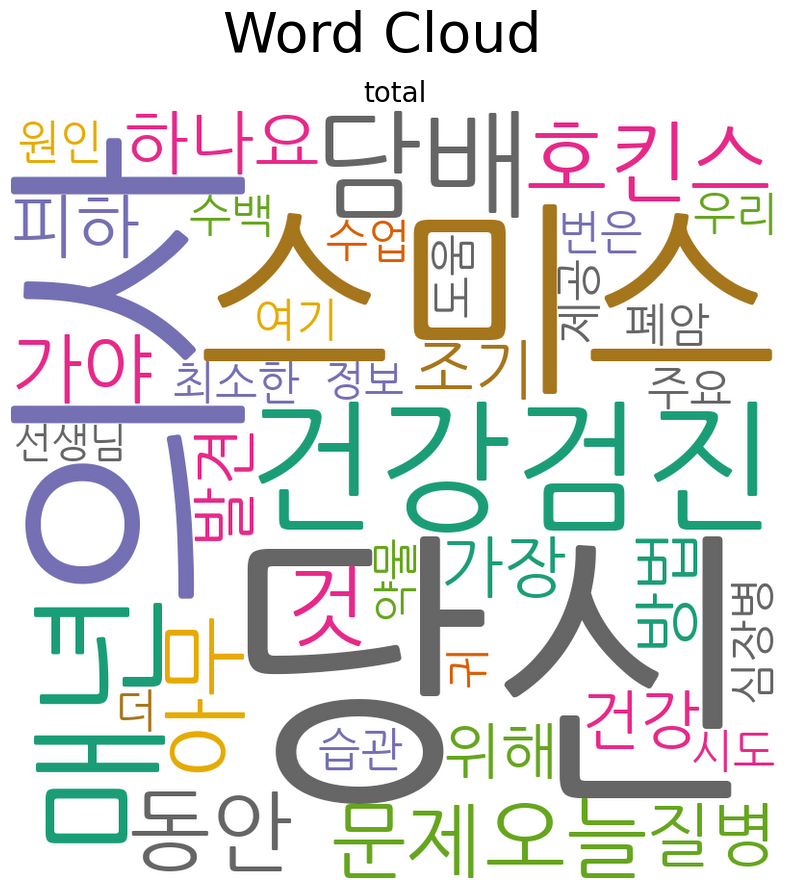

In [28]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def get_noun(text):
    okt = Okt()
    noun = okt.nouns(text)
    for i,v in enumerate(noun):
        if len(v)<2:
            noun.pop(i)
    count = Counter(noun)
    noun_list = count.most_common(100)
    return noun_list

def visualize(noun_list, title):
    # 워드클라우드 이미지 생성
    wc= WordCloud(
        font_path = 'NanumGothic-Regular.ttf', # 한글폰트 경로 설정
        background_color='white', # 배경 색깔 정하기
        colormap = 'Dark2', # 폰트 색깔 정하기
        width = 800,
        height = 800).generate_from_frequencies(dict(noun_list))
    plt.figure(figsize=(10,10)) #이미지 사이즈 지정
    plt.suptitle("Word Cloud", fontsize=40)
    plt.title(title, fontsize=20)
    plt.imshow(wc, interpolation='lanczos') #이미지의 부드럽기 정도
    plt.axis('off') #x y 축 숫자 제거
    plt.show() # 워드클라우드 이미지 확인
    return wc

noun_list = get_noun(train_df['dialogue'].iloc[0])           
total_reviews = visualize(noun_list, 'total') # 워드클라우드 시각화

## Special Token 추출

In [18]:
# 정규표현식 사용하기 
def reg_masking(text):
    pattern = r"#\w+#" # ## 사이의 값을 추출하는 정규식 패턴
    masked = re.findall(pattern, text)
    return masked

train_set = train_df['dialogue'].apply(lambda x:list(set(reg_masking(x))))
train_set[0]

['#Person2#', '#Person1#']

In [19]:
unique_token = []
for i in train_set.tolist(): # #사람2#
  for j in i:
    unique_token.append(j)

unique_token = list(set(unique_token))
unique_token

['#PassportNumber#',
 '#CardNumber#',
 '#Person3#',
 '#DateOfBirth#',
 '#Address#',
 '#CarNumber#',
 '#Email#',
 '#Person2#',
 '#Person6#',
 '#Person1#',
 '#Person#',
 '#Person7#',
 '#Person5#',
 '#PhoneNumber#',
 '#Person4#',
 '#SSN#']

In [31]:
val_set = val_df['dialogue'].apply(lambda x:list(set(reg_masking(x))))
val_set[0]

['#Person2#', '#Person1#']

In [32]:
test_set = test_df['dialogue'].apply(lambda x:list(set(reg_masking(x))))
test_set[0]

['#Person2#', '#Person1#']

## Token 개수 통계

In [20]:
model_name = "digit82/kobart-summarization" # digit82, gogamza
tokenizer = AutoTokenizer.from_pretrained(model_name)
special_tokens = ['#Person1#', '#Person2#', '#Person3#', '#PhoneNumber#', '#Address#', '#PassportNumber#',
                           '#DateOfBirth#', '#SSN#', '#CardNumber#', '#CarNumber#', '#Email#',
                           '#Person#', '#Person4#', '#Person5#', '#Person6#', '#Person7#', '#사람2#']
special_tokens_dict={'additional_special_tokens':special_tokens}
tokenizer.add_special_tokens(special_tokens_dict)

17

In [21]:
tokenizer.tokenize(train_df['dialogue'][0], add_special_tokens=True)

['#Person1#',
 '▁:',
 '▁안녕',
 '하세요',
 ',',
 '▁스미',
 '스',
 '씨',
 '.',
 '▁저는',
 '▁호',
 '킨',
 '스',
 '▁의사',
 '입니다.',
 '▁오늘',
 '▁왜',
 '▁오',
 '셨',
 '나요?\n',
 '#Person2#',
 '▁:',
 '▁건강',
 '검',
 '진을',
 '▁받는',
 '▁것이',
 '▁좋을',
 '▁것',
 '▁같아서',
 '요.\n',
 '#Person1#',
 '▁:',
 '▁그렇',
 '군',
 '요,',
 '▁당신은',
 '▁5년',
 '▁동안',
 '▁건강',
 '검',
 '진을',
 '▁받지',
 '▁않았',
 '습니다.',
 '▁매년',
 '▁받아야',
 '▁합니다.\n',
 '#Person2#',
 '▁:',
 '▁알고',
 '▁있습니다.',
 '▁하지만',
 '▁아무',
 '▁문제가',
 '▁없다면',
 '▁왜',
 '▁의사를',
 '▁만나',
 '러',
 '▁가야',
 '▁하나',
 '요?\n',
 '#Person1#',
 '▁:',
 '▁심각한',
 '▁질병',
 '을',
 '▁피',
 '하는',
 '▁가장',
 '▁좋은',
 '▁방법은',
 '▁이를',
 '▁조',
 '기에',
 '▁발견',
 '하는',
 '▁것입니다.',
 '▁그러니',
 '▁당신의',
 '▁건강을',
 '▁위해',
 '▁최소한',
 '▁매년',
 '▁한',
 '▁번',
 '은',
 '▁오',
 '세요.\n',
 '#Person2#',
 '▁:',
 '▁알',
 '겠습니다.\n',
 '#Person1#',
 '▁:',
 '▁여기',
 '▁보',
 '세요.',
 '▁당신의',
 '▁눈',
 '과',
 '▁귀',
 '는',
 '▁괜찮',
 '아',
 '▁보',
 '입니다.',
 '▁깊게',
 '▁숨을',
 '▁들이',
 '쉬',
 '세요.',
 '▁스미',
 '스',
 '씨,',
 '▁담배',
 '▁피',
 '우',
 '시',
 '나요?\n',
 '#Person2#',
 '▁:',


In [22]:
len(tokenizer.tokenize(train_df['dialogue'][0], add_special_tokens=True))

197

In [23]:
token_counts = []

for text in train_df['dialogue']:
    tokens = tokenizer.tokenize(text, add_special_tokens=True)
    token_counts.append(len(tokens))

print("Train Dialogue")
print("최대 토큰 개수:", max(token_counts))
print("최소 토큰 개수:", min(token_counts))
print("평균 토큰 개수:", sum(token_counts) / len(token_counts))

Train Dialogue
최대 토큰 개수: 950
최소 토큰 개수: 32
평균 토큰 개수: 158.59701372722165


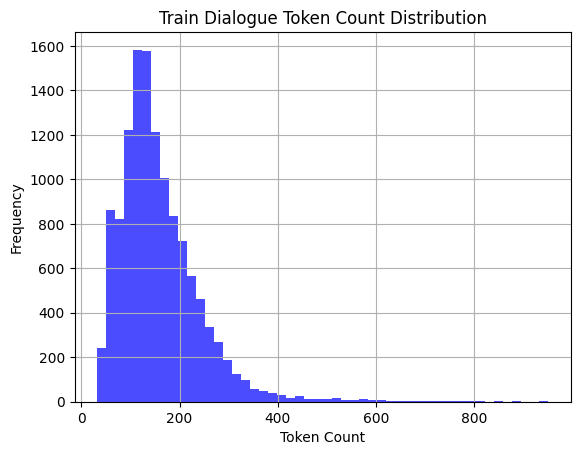

In [24]:
plt.hist(token_counts, bins=50, color='blue', alpha=0.7)
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Train Dialogue Token Count Distribution')
plt.grid(True)
plt.show()

In [25]:
token_counts = []

for text in train_df['summary']:
    tokens = tokenizer.tokenize(text, add_special_tokens=True)
    token_counts.append(len(tokens))

print("Train Summary")
print("최대 토큰 개수:", max(token_counts))
print("최소 토큰 개수:", min(token_counts))
print("평균 토큰 개수:", sum(token_counts) / len(token_counts))

Train Summary
최대 토큰 개수: 165
최소 토큰 개수: 7
평균 토큰 개수: 30.980733724010598


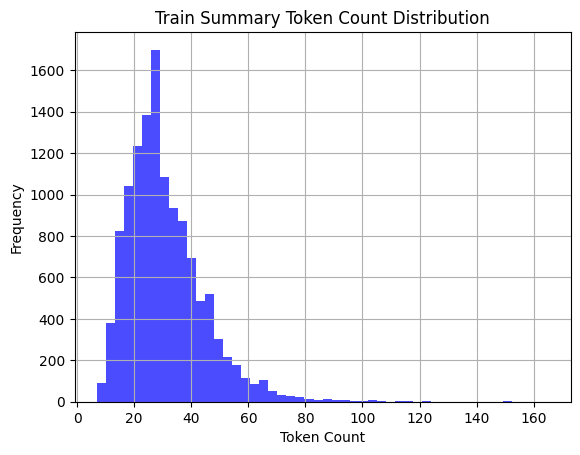

In [26]:
plt.hist(token_counts, bins=50, color='blue', alpha=0.7)
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Train Summary Token Count Distribution')
plt.grid(True)
plt.show()

In [27]:
token_counts = []

for text in val_df['dialogue']:
    tokens = tokenizer.tokenize(text, add_special_tokens=True)
    token_counts.append(len(tokens))

print("Validation Dialogue")
print("최대 토큰 개수:", max(token_counts))
print("최소 토큰 개수:", min(token_counts))
print("평균 토큰 개수:", sum(token_counts) / len(token_counts))

Validation Dialogue
최대 토큰 개수: 620
최소 토큰 개수: 46
평균 토큰 개수: 156.68737474949899


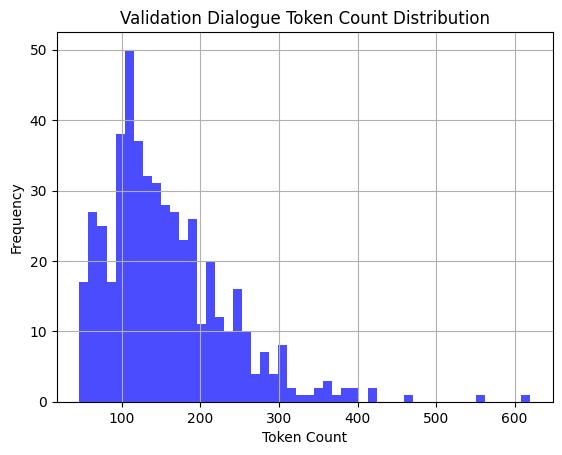

In [28]:
plt.hist(token_counts, bins=50, color='blue', alpha=0.7)
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Validation Dialogue Token Count Distribution')
plt.grid(True)
plt.show()

In [29]:
token_counts = []

for text in val_df['summary']:
    tokens = tokenizer.tokenize(text, add_special_tokens=True)
    token_counts.append(len(tokens))

print("Validation Summary")
print("최대 토큰 개수:", max(token_counts))
print("최소 토큰 개수:", min(token_counts))
print("평균 토큰 개수:", sum(token_counts) / len(token_counts))

Validation Summary
최대 토큰 개수: 89
최소 토큰 개수: 9
평균 토큰 개수: 28.795591182364728


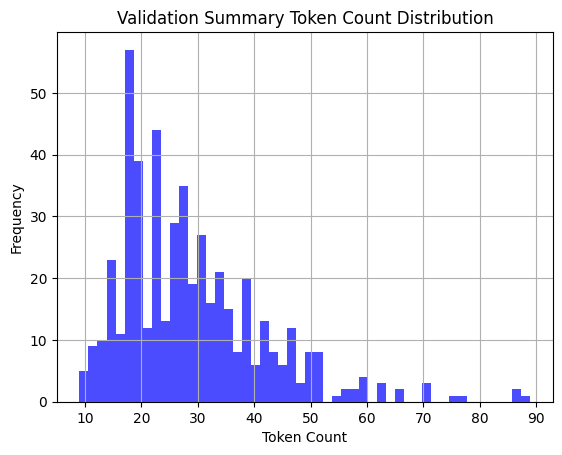

In [30]:
plt.hist(token_counts, bins=50, color='blue', alpha=0.7)
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Validation Summary Token Count Distribution')
plt.grid(True)
plt.show()

In [31]:
token_counts = []

for text in test_df['dialogue']:
    tokens = tokenizer.tokenize(text, add_special_tokens=True)
    token_counts.append(len(tokens))

print("Test Dialogue")
print("최대 토큰 개수:", max(token_counts))
print("최소 토큰 개수:", min(token_counts))
print("평균 토큰 개수:", sum(token_counts) / len(token_counts))

Test Dialogue
최대 토큰 개수: 1041
최소 토큰 개수: 38
평균 토큰 개수: 163.14629258517033


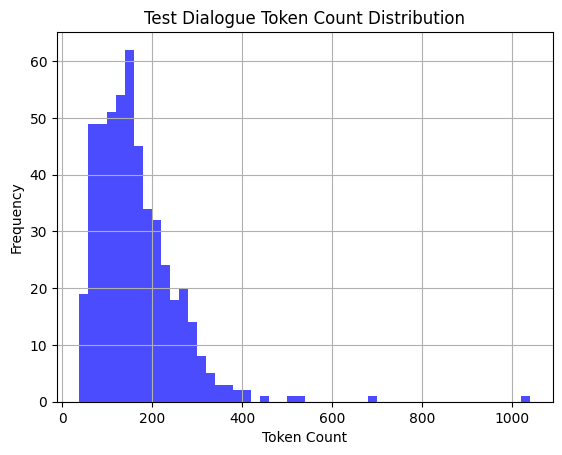

In [32]:
plt.hist(token_counts, bins=50, color='blue', alpha=0.7)
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Test Dialogue Token Count Distribution')
plt.grid(True)
plt.show()